In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

archivo = "Nasa_Daily_merge_2020_2025.csv"
df = pd.read_csv(archivo)

print("Dimensión del dataset:", df.shape)
display(df.head())
display(df.dtypes)

Dimensión del dataset: (83134, 11)


C:\Users\USER\AppData\Local\Temp\ipykernel_21620\960393408.py:7: DtypeWarning: Columns (0: -BEGIN HEADER-, 1: Unnamed: 1, 2: Unnamed: 2, 3: Unnamed: 3, 4: Unnamed: 4, 5: Unnamed: 5, 6: Unnamed: 6, 7: Unnamed: 7, 8: Unnamed: 8, 9: Unnamed: 9, 10: Unnamed: 10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(archivo)


,-BEGIN HEADER-,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,NASA/POWER Source Native Resolution Daily Data,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Dates (month/day/year): 01/01/2020 through 12/...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Location: Regional,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,elevation from MERRA-2: Average for 0.5 x 0.62...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,The value for missing source data that cannot ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


-BEGIN HEADER-    object
Unnamed: 1        object
Unnamed: 2        object
Unnamed: 3        object
Unnamed: 4        object
Unnamed: 5        object
Unnamed: 6        object
Unnamed: 7        object
Unnamed: 8        object
Unnamed: 9        object
Unnamed: 10       object
dtype: object

In [2]:
raw = pd.read_csv(archivo, header=None, dtype=str)

fin_encabezado = raw.index[
    raw.iloc[:, 0].astype(str).str.strip().eq("-END HEADER-")
]

print("Filas donde termina el encabezado:", fin_encabezado.tolist())
display(raw.iloc[:20])

Filas donde termina el encabezado: [8]


,0,1,2,3,4,5,6,7,8,9,10
0,-BEGIN HEADER-,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
1,NASA/POWER Source Native Resolution Daily Data,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Dates (month/day/year): 01/01/2020 through 12/...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Location: Regional,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,elevation from MERRA-2: Average for 0.5 x 0.62...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,The value for missing source data that cannot ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,parameter(s):,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,T2M MERRA-2 Temperature at 2 Meters (C),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,-END HEADER-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,LAT,LON,YEAR,MO,DY,T2M,PS,WS10M,WD10M,WS50M,WD50M


In [3]:
df = pd.read_csv(archivo, skiprows=9)

df["FECHA"] = pd.to_datetime(
    dict(year=df["YEAR"], month=df["MO"], day=df["DY"])
)

print("Dimensión limpia:", df.shape)
display(df.head())
display(df.dtypes)
%pip install sodapy

Dimensión limpia: (83125, 12)


,LAT,LON,YEAR,MO,DY,T2M,PS,WS10M,WD10M,WS50M,WD50M,FECHA
0,10.5,-75.000,2020,1,1,28.08,100.25,2.25,10.5,3.88,11.4,2020-01-01
1,10.5,-74.375,2020,1,1,28.56,98.38,1.64,351.2,2.82,5.6,2020-01-01
2,10.5,-73.750,2020,1,1,22.54,88.22,1.32,57.4,2.46,58.8,2020-01-01
3,10.5,-73.125,2020,1,1,21.69,89.90,2.00,40.4,3.52,33.1,2020-01-01
4,10.5,-72.500,2020,1,1,24.58,93.64,1.37,21.9,3.01,23.1,2020-01-01


LAT             float64
LON             float64
YEAR              int64
MO                int64
DY                int64
T2M             float64
PS              float64
WS10M           float64
WD10M           float64
WS50M           float64
WD50M           float64
FECHA    datetime64[us]
dtype: object

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install sodapy

Note: you may need to restart the kernel to use updated packages.


In [5]:
from sodapy import Socrata

print("Sodapy funciona correctamente")

Sodapy funciona correctamente


In [6]:
import pandas as pd
from sodapy import Socrata

client = Socrata("www.datos.gov.co", None)

results = client.get("sgfv-3yp8", limit=2000)

df = pd.DataFrame.from_records(results)

In [7]:
df.shape

(2000, 12)

# 1. Base de Datos

## Dataset: NASA POWER Reanálisis MERRA-2 (2020–2025)

In [8]:
# CELDA 1: Importes y carga del archivo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# El archivo está en la misma carpeta que este notebook
nasa_path = "Nasa_Daily_merge_2020_2025.csv"

# NASA POWER contiene 9 líneas de metadatos antes del encabezado
nasa = pd.read_csv(nasa_path, skiprows=9)

# Renombrar columnas
nasa.columns = [
    'LAT', 'LON', 'YEAR', 'MONTH', 'DAY',
    'T2M', 'PS', 'WS10M', 'WD10M', 'WS50M', 'WD50M'
]

# Crear la fecha
nasa['FECHA'] = pd.to_datetime(
    dict(
        year=nasa['YEAR'],
        month=nasa['MONTH'],
        day=nasa['DAY']
    )
)

# Ordenar cada punto geográfico cronológicamente
nasa = nasa.sort_values(
    ['LAT', 'LON', 'FECHA']
).reset_index(drop=True)

print(f"Dataset cargado: {len(nasa)} filas, {nasa.shape[1]} columnas")
print(f"Rango temporal: {nasa['FECHA'].min().date()} a {nasa['FECHA'].max().date()}")
print(
    "Puntos de malla:",
    nasa[['LAT', 'LON']].drop_duplicates().shape[0]
)

Dataset cargado: 83125 filas, 12 columnas
Rango temporal: 2020-01-01 a 2025-10-01
Puntos de malla: 42


In [9]:
# CELDA 2: Diccionario de variables

diccionario = pd.DataFrame({
    'Variable': [
        'LAT', 'LON', 'T2M', 'PS',
        'WS10M', 'WD10M', 'WS50M', 'WD50M', 'FECHA'
    ],

    'Descripción': [
        'Latitud del punto de malla',
        'Longitud del punto de malla',
        'Temperatura del aire a 2 metros',
        'Presión atmosférica superficial',
        'Velocidad del viento a 10 metros',
        'Dirección del viento a 10 metros',
        'Velocidad del viento a 50 metros',
        'Dirección del viento a 50 metros',
        'Fecha de observación'
    ],

    'Unidad': [
        'grados',
        'grados',
        '°C',
        'kPa',
        'm/s',
        'grados (0-360)',
        'm/s',
        'grados (0-360)',
        'YYYY-MM-DD'
    ]
})

diccionario

,Variable,Descripción,Unidad
0,LAT,Latitud del punto de malla,grados
1,LON,Longitud del punto de malla,grados
2,T2M,Temperatura del aire a 2 metros,°C
3,PS,Presión atmosférica superficial,kPa
4,WS10M,Velocidad del viento a 10 metros,m/s
5,WD10M,Dirección del viento a 10 metros,grados (0-360)
6,WS50M,Velocidad del viento a 50 metros,m/s
7,WD50M,Dirección del viento a 50 metros,grados (0-360)
8,FECHA,Fecha de observación,YYYY-MM-DD


In [10]:
# CELDA 3: Calidad de datos

variables_meteo = [
    'T2M', 'PS', 'WS10M',
    'WD10M', 'WS50M', 'WD50M'
]

print("=" * 70)
print("ANÁLISIS DE CALIDAD DE DATOS")
print("=" * 70)

# 1. Valores faltantes
calidad = pd.DataFrame({
    'Faltantes': nasa[variables_meteo].isna().sum(),
    'Completitud (%)': (
        nasa[variables_meteo].notna().mean() * 100
    ).round(2)
})

print("\n1. COMPLETITUD")
display(calidad)

# 2. Estadísticas descriptivas
print("\n2. ESTADÍSTICAS DESCRIPTIVAS")
display(
    nasa[variables_meteo]
    .describe()
    .round(2)
)

# 3. Valores mínimos y máximos observados
rangos_observados = pd.DataFrame({
    'Mínimo observado': nasa[variables_meteo].min(),
    'Máximo observado': nasa[variables_meteo].max()
}).round(2)

print("\n3. RANGOS OBSERVADOS")
display(rangos_observados)

# 4. Duplicados estación espacial-fecha
duplicados = nasa.duplicated(
    subset=['LAT', 'LON', 'FECHA']
).sum()

print(
    "\nRegistros duplicados "
    "(LAT, LON, FECHA):",
    duplicados
)

ANÁLISIS DE CALIDAD DE DATOS

1. COMPLETITUD


,Faltantes,Completitud (%)
T2M,0,100.0
PS,0,100.0
WS10M,0,100.0
WD10M,0,100.0
WS50M,0,100.0
WD50M,0,100.0



2. ESTADÍSTICAS DESCRIPTIVAS


,T2M,PS,WS10M,WD10M,WS50M,WD50M
count,83125.00,83125.00,83125.00,83125.00,83125.00,83125.00
mean,27.57,98.87,5.23,94.50,6.56,92.87
std,2.29,3.61,3.46,86.65,3.72,85.21
min,18.14,87.91,0.39,0.00,0.39,0.00
25%,26.49,98.48,1.88,53.80,3.08,53.90
50%,27.82,100.50,4.63,69.90,5.96,70.20
75%,28.96,100.94,8.24,81.10,9.72,81.10
max,36.00,101.57,16.11,360.00,19.05,360.00



3. RANGOS OBSERVADOS


,Mínimo observado,Máximo observado
T2M,18.14,36.00
PS,87.91,101.57
WS10M,0.39,16.11
WD10M,0.00,360.00
WS50M,0.39,19.05
WD50M,0.00,360.00



Registros duplicados (LAT, LON, FECHA): 0


In [11]:
# CELDA 4: Cobertura espacial y temporal

print("=" * 70)
print("COBERTURA ESPACIAL Y TEMPORAL")
print("=" * 70)

# Cobertura espacial
n_puntos = nasa[['LAT', 'LON']].drop_duplicates().shape[0]

print("\nCOBERTURA ESPACIAL")
print(f"Latitud mínima:  {nasa['LAT'].min():.3f}°")
print(f"Latitud máxima:  {nasa['LAT'].max():.3f}°")
print(f"Longitud mínima: {nasa['LON'].min():.3f}°")
print(f"Longitud máxima: {nasa['LON'].max():.3f}°")
print(f"Puntos de malla únicos: {n_puntos}")

# Cobertura temporal
fecha_inicio = nasa['FECHA'].min()
fecha_fin = nasa['FECHA'].max()

print("\nCOBERTURA TEMPORAL")
print(f"Fecha inicial: {fecha_inicio.date()}")
print(f"Fecha final:   {fecha_fin.date()}")
print(f"Duración: {(fecha_fin - fecha_inicio).days + 1} días calendario")

# Comprobar continuidad temporal por punto de malla
continuidad = []

for (lat, lon), grupo in nasa.groupby(['LAT', 'LON']):

    fechas = grupo['FECHA'].sort_values()

    dias_esperados = (
        fechas.max() - fechas.min()
    ).days + 1

    dias_observados = fechas.nunique()

    continuidad.append({
        'LAT': lat,
        'LON': lon,
        'Inicio': fechas.min(),
        'Fin': fechas.max(),
        'Días esperados': dias_esperados,
        'Días observados': dias_observados,
        'Días faltantes': dias_esperados - dias_observados
    })

continuidad_df = pd.DataFrame(continuidad)

print("\nCONTINUIDAD TEMPORAL POR PUNTO DE MALLA")
display(continuidad_df)

print(
    "\nTotal de días faltantes:",
    continuidad_df['Días faltantes'].sum()
)

COBERTURA ESPACIAL Y TEMPORAL

COBERTURA ESPACIAL
Latitud mínima:  10.000°
Latitud máxima:  12.500°
Longitud mínima: -75.000°
Longitud máxima: -71.250°
Puntos de malla únicos: 42

COBERTURA TEMPORAL
Fecha inicial: 2020-01-01
Fecha final:   2025-10-01
Duración: 2101 días calendario

CONTINUIDAD TEMPORAL POR PUNTO DE MALLA


,LAT,LON,Inicio,Fin,Días esperados,Días observados,Días faltantes
0,10.0,-75.000,2022-01-01,2025-10-01,1370,1370,0
1,10.0,-74.375,2022-01-01,2025-10-01,1370,1370,0
2,10.0,-73.750,2022-01-01,2025-10-01,1370,1370,0
3,10.0,-73.125,2022-01-01,2025-10-01,1370,1370,0
4,10.0,-72.500,2022-01-01,2025-10-01,1370,1370,0
5,10.0,-71.875,2022-01-01,2025-10-01,1370,1370,0
6,10.0,-71.250,2022-01-01,2025-10-01,1370,1370,0
7,10.5,-75.000,2020-01-01,2025-10-01,2101,2101,0
8,10.5,-74.375,2020-01-01,2025-10-01,2101,2101,0
9,10.5,-73.750,2020-01-01,2025-10-01,2101,2101,0



Total de días faltantes: 0


In [12]:
# CELDA 5: Definición del problema predictivo

print("=" * 70)
print("DEFINICIÓN DEL PROBLEMA")
print("=" * 70)

print("\nPREGUNTA DE INVESTIGACIÓN:")
print(
    "¿Puede predecirse la velocidad del viento a 10 metros "
    "(WS10M) del día siguiente"
)
print(
    "en un punto de malla a partir de las condiciones "
    "meteorológicas observadas en el día actual?"
)

print("\nTIPO DE PROBLEMA:")
print("Regresión temporal (serie de tiempo).")

print("\nVARIABLE OBJETIVO:")
print("y(t+1) = WS10M(t+1)")

print("\nVARIABLES PREDICTORAS EN EL TIEMPO t:")
print("  - WS10M(t): velocidad del viento a 10 m")
print("  - WD10M(t): dirección del viento a 10 m")
print("  - T2M(t): temperatura del aire a 2 m")
print("  - PS(t): presión atmosférica superficial")

print("\nHORIZONTE DE PREDICCIÓN:")
print("1 día adelante (24 horas)")

print("\nVALIDACIÓN:")
print(
    "La partición de entrenamiento y validación deberá "
    "respetar el orden temporal."
)

DEFINICIÓN DEL PROBLEMA

PREGUNTA DE INVESTIGACIÓN:
¿Puede predecirse la velocidad del viento a 10 metros (WS10M) del día siguiente
en un punto de malla a partir de las condiciones meteorológicas observadas en el día actual?

TIPO DE PROBLEMA:
Regresión temporal (serie de tiempo).

VARIABLE OBJETIVO:
y(t+1) = WS10M(t+1)

VARIABLES PREDICTORAS EN EL TIEMPO t:
  - WS10M(t): velocidad del viento a 10 m
  - WD10M(t): dirección del viento a 10 m
  - T2M(t): temperatura del aire a 2 m
  - PS(t): presión atmosférica superficial

HORIZONTE DE PREDICCIÓN:
1 día adelante (24 horas)

VALIDACIÓN:
La partición de entrenamiento y validación deberá respetar el orden temporal.


In [13]:
# CELDA 6: Línea base de persistencia

from sklearn.metrics import mean_squared_error, r2_score

print("=" * 70)
print("LÍNEA BASE: MODELO DE PERSISTENCIA")
print("=" * 70)

# Copia para no modificar el DataFrame original
persistencia = nasa.copy()

# Obtener, dentro de cada punto de malla:
# - la velocidad del viento de la siguiente observación
# - la fecha de esa siguiente observación
persistencia['WS10M_tomorrow'] = (
    persistencia
    .groupby(['LAT', 'LON'])['WS10M']
    .shift(-1)
)

persistencia['FECHA_tomorrow'] = (
    persistencia
    .groupby(['LAT', 'LON'])['FECHA']
    .shift(-1)
)

# Verificar que la siguiente observación sea exactamente el día siguiente
persistencia['salto_dias'] = (
    persistencia['FECHA_tomorrow'] -
    persistencia['FECHA']
).dt.days

# Conservar solamente pares t -> t+1 día
persistencia = persistencia[
    persistencia['salto_dias'] == 1
].copy()

print(
    f"Pares válidos t -> t+1 día: "
    f"{len(persistencia)}"
)

print(
    "Saltos temporales utilizados:",
    persistencia['salto_dias'].unique()
)

# Persistencia:
# predicción para mañana = velocidad observada hoy
y_real = persistencia['WS10M_tomorrow']
y_pred_persistencia = persistencia['WS10M']

rmse_persistencia = np.sqrt(
    mean_squared_error(
        y_real,
        y_pred_persistencia
    )
)

r2_persistencia = r2_score(
    y_real,
    y_pred_persistencia
)

print("\nRESULTADOS GLOBALES")
print(f"RMSE persistencia: {rmse_persistencia:.3f} m/s")
print(f"R² persistencia:   {r2_persistencia:.3f}")

LÍNEA BASE: MODELO DE PERSISTENCIA
Pares válidos t -> t+1 día: 83083
Saltos temporales utilizados: [1.]

RESULTADOS GLOBALES
RMSE persistencia: 1.700 m/s
R² persistencia:   0.758


In [14]:
persistencia[
    [
        'LAT',
        'LON',
        'FECHA',
        'WS10M',
        'FECHA_tomorrow',
        'WS10M_tomorrow',
        'salto_dias'
    ]
].head(10)

,LAT,LON,FECHA,WS10M,FECHA_tomorrow,WS10M_tomorrow,salto_dias
0,10.0,-75.0,2022-01-01,1.23,2022-01-02,1.38,1.0
1,10.0,-75.0,2022-01-02,1.38,2022-01-03,1.41,1.0
2,10.0,-75.0,2022-01-03,1.41,2022-01-04,1.47,1.0
3,10.0,-75.0,2022-01-04,1.47,2022-01-05,1.57,1.0
4,10.0,-75.0,2022-01-05,1.57,2022-01-06,1.48,1.0
5,10.0,-75.0,2022-01-06,1.48,2022-01-07,1.43,1.0
6,10.0,-75.0,2022-01-07,1.43,2022-01-08,1.45,1.0
7,10.0,-75.0,2022-01-08,1.45,2022-01-09,1.40,1.0
8,10.0,-75.0,2022-01-09,1.40,2022-01-10,1.25,1.0
9,10.0,-75.0,2022-01-10,1.25,2022-01-11,1.26,1.0


In [15]:
import sys
print(sys.executable)

c:\Users\USER\miniconda3\envs\ml_env\python.exe


In [16]:
# CELDA 7: Resumen de la base de datos y del problema

print("=" * 70)
print("RESUMEN DE LA SECCIÓN 1")
print("=" * 70)

print("\nDATASET")
print("Fuente: NASA POWER - Reanálisis MERRA-2")
print(f"Observaciones totales: {len(nasa):,}")
print(
    "Puntos de malla únicos:",
    nasa[['LAT', 'LON']].drop_duplicates().shape[0]
)
print(
    f"Periodo global observado: "
    f"{nasa['FECHA'].min().date()} a "
    f"{nasa['FECHA'].max().date()}"
)

print("\nCALIDAD DE LOS DATOS")
print(
    "Valores faltantes en variables meteorológicas:",
    nasa[variables_meteo].isna().sum().sum()
)
print(
    "Duplicados (LAT, LON, FECHA):",
    nasa.duplicated(
        subset=['LAT', 'LON', 'FECHA']
    ).sum()
)
print(
    "Días faltantes dentro del periodo observado "
    "de cada punto:",
    continuidad_df['Días faltantes'].sum()
)

print("\nPROBLEMA PREDICTIVO")
print("Tipo: Regresión temporal")
print("Variable objetivo: WS10M del día siguiente")
print("Horizonte de predicción: 1 día")

print("\nLÍNEA BASE DE PERSISTENCIA")
print(f"Pares diarios evaluados: {len(persistencia):,}")
print(f"RMSE: {rmse_persistencia:.3f} m/s")
print(f"R²:   {r2_persistencia:.3f}")

print("\nCRITERIO PARA LOS MODELOS POSTERIORES")
print(
    "Los modelos serán evaluados respetando "
    "el orden temporal de los datos."
)

RESUMEN DE LA SECCIÓN 1

DATASET
Fuente: NASA POWER - Reanálisis MERRA-2
Observaciones totales: 83,125
Puntos de malla únicos: 42
Periodo global observado: 2020-01-01 a 2025-10-01

CALIDAD DE LOS DATOS
Valores faltantes en variables meteorológicas: 0
Duplicados (LAT, LON, FECHA): 0
Días faltantes dentro del periodo observado de cada punto: 0

PROBLEMA PREDICTIVO
Tipo: Regresión temporal
Variable objetivo: WS10M del día siguiente
Horizonte de predicción: 1 día

LÍNEA BASE DE PERSISTENCIA
Pares diarios evaluados: 83,083
RMSE: 1.700 m/s
R²:   0.758

CRITERIO PARA LOS MODELOS POSTERIORES
Los modelos serán evaluados respetando el orden temporal de los datos.


# 2. Análisis Exploratorio de Datos (EDA)

En esta sección se analiza el comportamiento de las variables meteorológicas,
con especial atención a la velocidad del viento a 10 metros (WS10M), que
corresponde a la variable objetivo del problema predictivo.

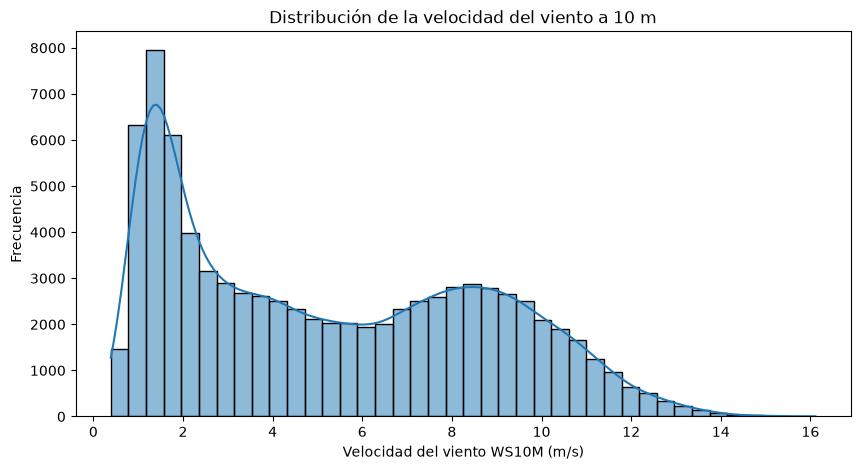

In [17]:
# EDA 1: Distribución de la velocidad del viento a 10 m

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=nasa,
    x='WS10M',
    bins=40,
    kde=True,
    ax=ax
)

ax.set_title(
    'Distribución de la velocidad del viento a 10 m'
)
ax.set_xlabel('Velocidad del viento WS10M (m/s)')
ax.set_ylabel('Frecuencia')

plt.show()

In [18]:
# Comprobación de las frecuencias del histograma de WS10M

frecuencias, limites = np.histogram(
    nasa['WS10M'],
    bins=40
)

tabla_histograma = pd.DataFrame({
    'Límite inferior (m/s)': limites[:-1],
    'Límite superior (m/s)': limites[1:],
    'Frecuencia': frecuencias
})

tabla_histograma = tabla_histograma.round({
    'Límite inferior (m/s)': 2,
    'Límite superior (m/s)': 2
})

tabla_histograma

,Límite inferior (m/s),Límite superior (m/s),Frecuencia
0,0.39,0.78,1472
1,0.78,1.18,6317
2,1.18,1.57,7957
3,1.57,1.96,6109
4,1.96,2.36,3991
5,2.36,2.75,3157
6,2.75,3.14,2893
7,3.14,3.53,2687
8,3.53,3.93,2618
9,3.93,4.32,2511


In [19]:
print("Suma de las frecuencias:", frecuencias.sum())
print("Número de observaciones:", len(nasa))

Suma de las frecuencias: 83125
Número de observaciones: 83125


In [20]:
# EDA 2: Velocidad media del viento por punto de malla

viento_por_punto = (
    nasa
    .groupby(['LAT', 'LON'])['WS10M']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .reset_index()
)

viento_por_punto.columns = [
    'LAT',
    'LON',
    'Media_WS10M',
    'Desv_est_WS10M',
    'Min_WS10M',
    'Max_WS10M',
    'Observaciones'
]

viento_por_punto = viento_por_punto.sort_values(
    'Media_WS10M',
    ascending=False
).reset_index(drop=True)

viento_por_punto.round(2)

,LAT,LON,Media_WS10M,Desv_est_WS10M,Min_WS10M,Max_WS10M,Observaciones
0,12.0,-75.00,8.76,3.42,0.96,16.11,2101
1,12.0,-74.38,8.59,3.28,0.60,15.32,2101
2,12.5,-75.00,8.52,3.16,0.86,15.24,2101
3,11.5,-71.25,8.42,2.54,1.26,13.40,2101
4,11.5,-75.00,8.38,3.42,0.85,16.01,2101
5,12.5,-74.38,8.36,3.08,0.70,14.62,2101
6,12.0,-71.25,8.26,2.47,1.24,13.64,2101
7,12.5,-71.25,7.97,2.28,1.39,13.11,2101
8,12.5,-73.75,7.90,2.86,0.60,13.83,2101
9,12.0,-73.75,7.72,2.78,0.47,13.70,2101


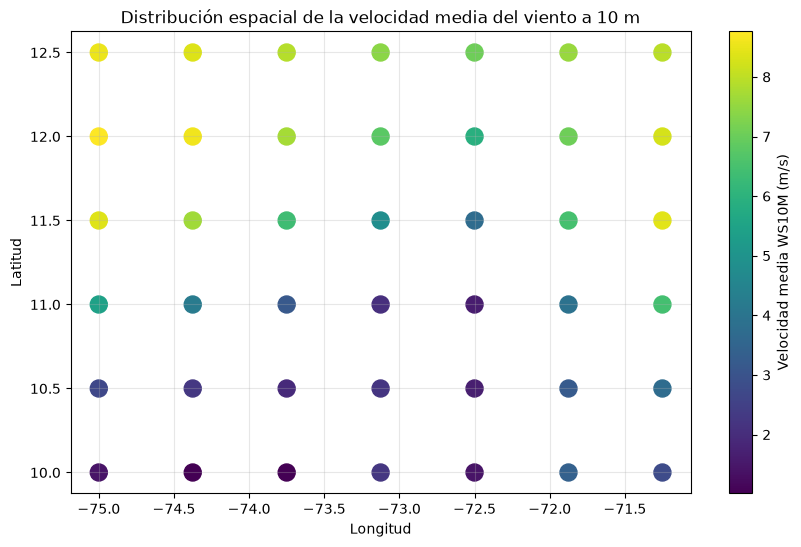

In [21]:
# EDA 3: Distribución espacial de la velocidad media del viento

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    viento_por_punto['LON'],
    viento_por_punto['LAT'],
    c=viento_por_punto['Media_WS10M'],
    s=150
)

plt.colorbar(
    scatter,
    label='Velocidad media WS10M (m/s)'
)

plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title(
    'Distribución espacial de la velocidad media del viento a 10 m'
)

plt.grid(alpha=0.3)

plt.show()

In [22]:
# EDA 4: Comportamiento mensual de la velocidad del viento

viento_mensual = (
    nasa
    .groupby('MONTH')['WS10M']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

viento_mensual.columns = [
    'Mes',
    'Media_WS10M',
    'Desv_est_WS10M',
    'Observaciones'
]

viento_mensual.round(2)

,Mes,Media_WS10M,Desv_est_WS10M,Observaciones
0,1,5.90,3.62,7378
1,2,6.19,3.64,6741
2,3,6.09,3.48,7378
3,4,5.79,3.44,7140
4,5,5.33,3.52,7378
5,6,5.37,3.69,7140
6,7,5.51,3.59,7378
7,8,4.85,3.31,7378
8,9,3.98,2.77,7140
9,10,3.89,2.73,6118


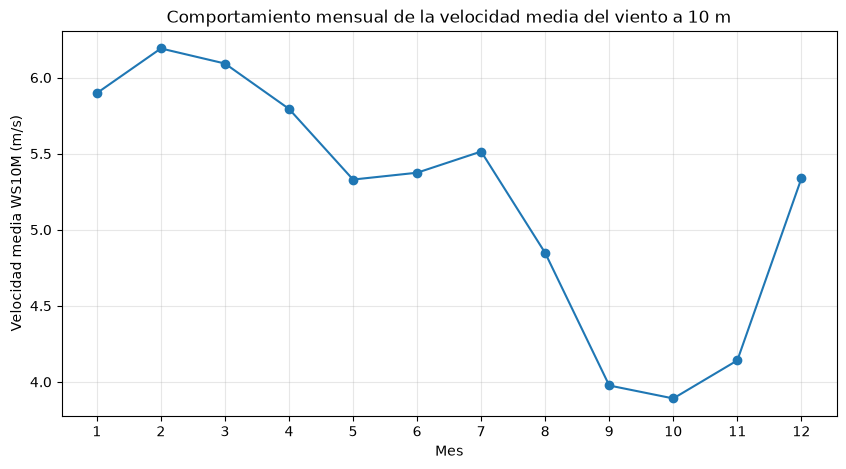

In [23]:
# EDA 5: Evolución mensual de la velocidad media del viento

plt.figure(figsize=(10, 5))

plt.plot(
    viento_mensual['Mes'],
    viento_mensual['Media_WS10M'],
    marker='o'
)

plt.xticks(range(1, 13))

plt.xlabel('Mes')
plt.ylabel('Velocidad media WS10M (m/s)')
plt.title(
    'Comportamiento mensual de la velocidad media del viento a 10 m'
)

plt.grid(alpha=0.3)

plt.show()

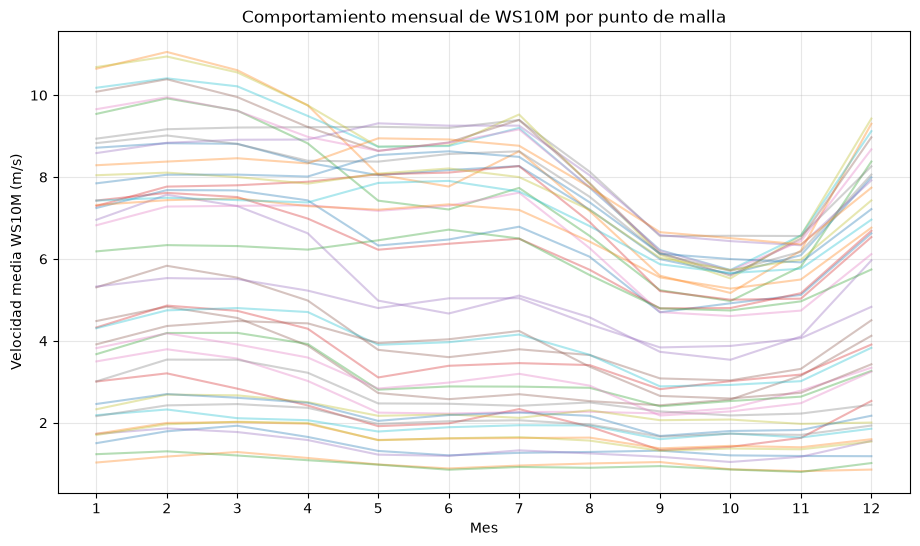

In [24]:
# EDA 6: Patrón mensual dentro de cada punto de malla

mensual_por_punto = (
    nasa
    .groupby(['LAT', 'LON', 'MONTH'])['WS10M']
    .mean()
    .reset_index()
)

plt.figure(figsize=(11, 6))

for (lat, lon), grupo in mensual_por_punto.groupby(['LAT', 'LON']):
    plt.plot(
        grupo['MONTH'],
        grupo['WS10M'],
        alpha=0.35
    )

plt.xticks(range(1, 13))

plt.xlabel('Mes')
plt.ylabel('Velocidad media WS10M (m/s)')
plt.title(
    'Comportamiento mensual de WS10M por punto de malla'
)

plt.grid(alpha=0.3)

plt.show()

### Patrón espacial y temporal de WS10M

El análisis exploratorio muestra diferencias importantes en la velocidad media
del viento entre los puntos de malla. Asimismo, al estudiar el comportamiento
mensual dentro de cada punto, se observa un patrón temporal similar en una parte
considerable de las ubicaciones, aunque con diferentes niveles de velocidad.

Estos resultados indican que la velocidad del viento presenta tanto una
componente espacial como una componente temporal. Por esta razón, las etapas
posteriores de modelado y validación deberán preservar la estructura temporal
de los datos y considerar la información asociada a la ubicación geográfica.

In [25]:
# EDA 7: Matriz de correlación entre variables meteorológicas

variables_correlacion = [
    'T2M',
    'PS',
    'WS10M',
    'WD10M',
    'WS50M',
    'WD50M'
]

matriz_correlacion = (
    nasa[variables_correlacion]
    .corr()
    .round(3)
)

matriz_correlacion

,T2M,PS,WS10M,WD10M,WS50M,WD50M
T2M,1.000,0.637,0.079,0.128,0.080,0.109
PS,0.637,1.000,0.520,0.033,0.518,0.029
WS10M,0.079,0.520,1.000,-0.291,0.993,-0.279
WD10M,0.128,0.033,-0.291,1.000,-0.303,0.910
WS50M,0.080,0.518,0.993,-0.303,1.000,-0.290
WD50M,0.109,0.029,-0.279,0.910,-0.290,1.000
